In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

**Regression trees partition the feature space recursively to predict continuous target values, minimising mean squared error at each node without assuming linearity, thus capturing complex relationships in data.**

## Introduction to Regression Trees
Regression trees extend the decision tree framework to continuous target variables, constructing a piecewise constant model through binary splits. Unlike classification trees that optimise for purity using Gini or entropy, regression trees minimise variance in target values within nodes. This approach allows modelling of non-linear dependencies, as the tree adapts to local data structures rather than imposing a global functional form.

The process begins at the root node with the full dataset and recursively splits based on features that reduce intra-node variance most effectively. Leaves represent regions where predictions are the mean of the target values in that subset. This non-parametric nature makes regression trees robust to outliers and irrelevant features, though prone to overfitting without constraints such as maximum depth or minimum leaf samples.

## Theoretical Foundations
At each node, the tree evaluates potential splits to minimise the **mean squared error** (MSE), which serves as the impurity criterion for regression.

The MSE for a node is:
$$
I(\text{node}) = \text{MSE}(\text{node}) = \frac{1}{N_{\text{node}}} \sum_{i \in \text{node}} (y^{(i)} - \hat{y}_{\text{node}})^2,
$$
where $N_{\text{node}}$ is the number of samples in the node, $y^{(i)}$ are the target values, and $\hat{y}_{\text{node}}$ is the mean target value:
$$
\hat{y}_{\text{node}} = \frac{1}{N_{\text{node}}} \sum_{i \in \text{node}} y^{(i)}.
$$

The optimal split on feature $f$ at point $sp$ maximises the reduction in weighted MSE:
$$
\Delta \text{MSE}(f, sp) = \text{MSE}(\text{parent}) - \left( \frac{N_{\text{left}}}{N} \text{MSE}(\text{left}) + \frac{N_{\text{right}}}{N} \text{MSE}(\text{right}) \right).
$$
This variance reduction mirrors information gain in classification but focuses on minimising prediction error rather than class uncertainty.

Predictions for new instances traverse the tree to a leaf, yielding:
$$
\hat{y}_{\text{pred}}(\text{leaf}) = \frac{1}{N_{\text{leaf}}} \sum_{i \in \text{leaf}} y^{(i)},
$$
the average target in that leaf. This results in stepwise constant functions, approximating non-linear trends effectively but potentially creating discontinuities at boundaries.

Stopping criteria prevent excessive depth: if $\Delta \text{MSE} < \epsilon$ or node size falls below a threshold, the node becomes a leaf. Hyperparameters like `min_samples_leaf` (e.g., fraction of total samples) enforce generalisation.

### Implementation in Scikit-Learn
Scikit-learn's `DecisionTreeRegressor` facilitates regression tree construction, with MSE as the default criterion. The workflow includes data splitting, instantiation with constraints, fitting, prediction, and error evaluation using root mean squared error (RMSE).

A self-contained example using a synthetic regression dataset illustrates the process:


In [2]:
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# Generate a synthetic regression dataset
X, y = make_regression(n_samples=1000, n_features=5, noise=0.1, random_state=3)

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

# Instantiate regressor with constraints
regressor = DecisionTreeRegressor(max_depth=4, min_samples_leaf=0.1, random_state=3)

# Fit to training data
regressor.fit(X_train, y_train)

# Predict on test set
y_pred = regressor.predict(X_test)

# Compute MSE and RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
print(f"Test set RMSE: {rmse:.4f}")

Test set RMSE: 117.8434


Here, `max_depth=4` limits complexity, while `min_samples_leaf=0.1` ensures leaves contain at least 10% of training samples, reducing overfitting. The `random_state` aids reproducibility.

To visualise the tree:

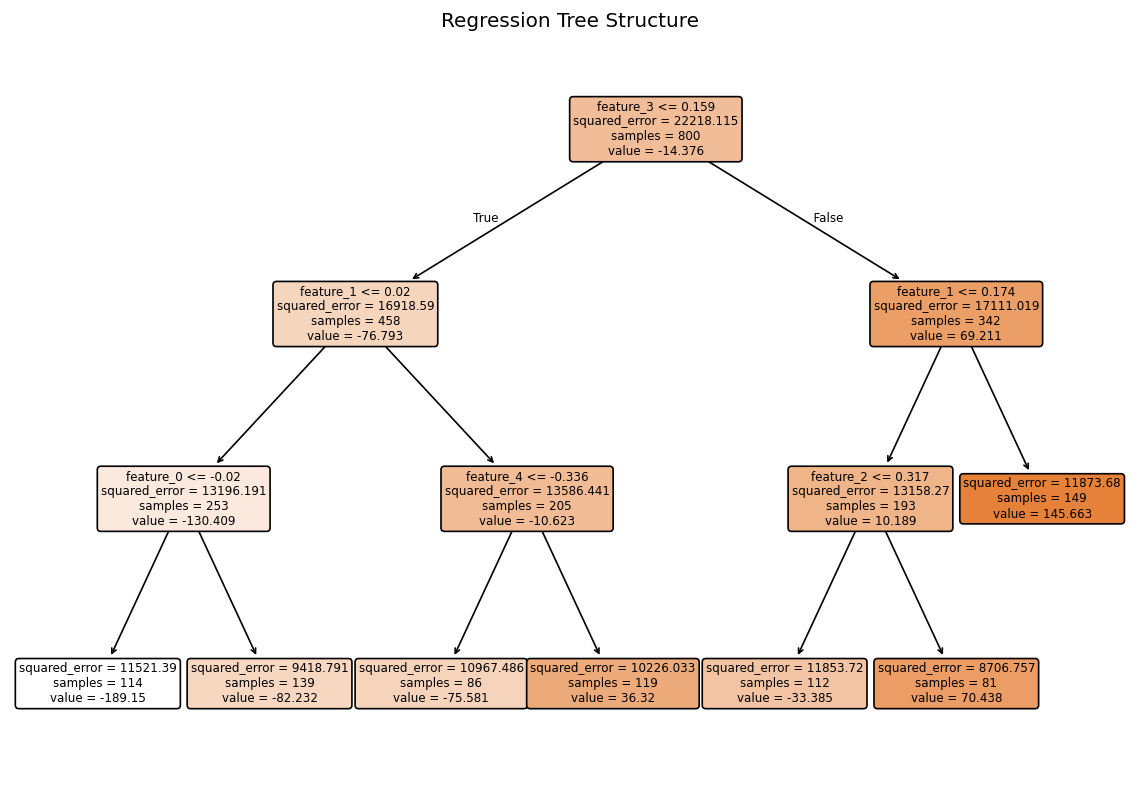

In [4]:
from sklearn.tree import plot_tree

# Plot the regression tree
fig, ax = plt.subplots(figsize=(12, 8), dpi=120)
plot_tree(
	regressor,
	feature_names=[f"feature_{i}" for i in range(X.shape[1])],
	filled=True,
	rounded=True,
	ax=ax,
)
ax.set_title("Regression Tree Structure")
plt.show()

This diagram displays nodes with split details, sample counts, MSE values, and predicted means.

### Evaluation and Comparison with Linear Models
Performance is assessed via RMSE on held-out data, quantifying average prediction deviation:
$$
\text{RMSE} = \sqrt{\frac{1}{N_{\text{test}}} \sum_{i=1}^{N_{\text{test}}} (y_i - \hat{y}_i)^2}.
$$
Lower RMSE indicates better fit, but cross-validation provides robust estimates.

Regression trees excel over linear regression in non-linear scenarios. Linear models assume:
$$
y = \beta_0 + \sum_{j=1}^{p} \beta_j x_j + \epsilon,
$$
yielding smooth predictions but failing on curved relationships. Trees, conversely, produce flexible, stepwise approximations.


To compare visually, the following code plots predictions from both models on a 1D feature subset:

In [5]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# Generate 1D regression data for visualisation
X, y = make_regression(n_samples=300, n_features=1, noise=10, random_state=3)
X = X.flatten()  # For 1D plotting

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

# Train models
lin_reg = LinearRegression()
lin_reg.fit(X_train.reshape(-1, 1), y_train)

tree_reg = DecisionTreeRegressor(max_depth=4, random_state=3)
tree_reg.fit(X_train.reshape(-1, 1), y_train)

# Generate prediction points
X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_lin_pred = lin_reg.predict(X_plot)
y_tree_pred = tree_reg.predict(X_plot)


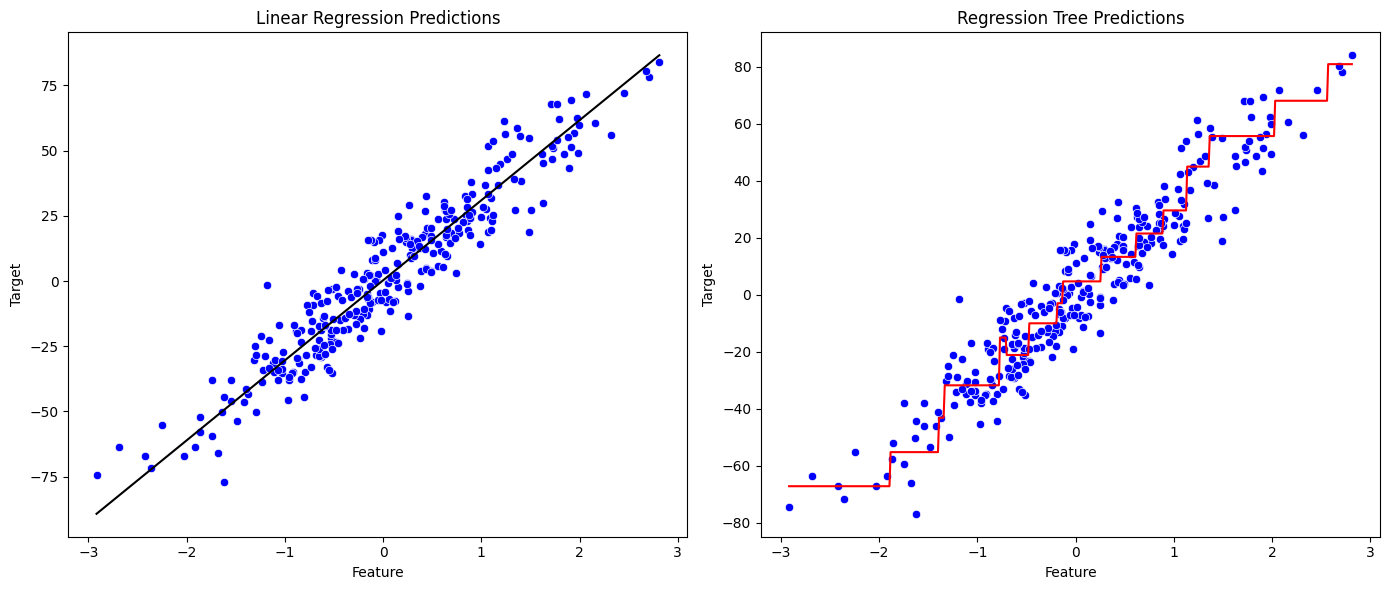

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Linear Regression
sns.scatterplot(x=X, y=y, color="blue", ax=axes[0])
sns.lineplot(x=X_plot.flatten(), y=y_lin_pred, color="black", ax=axes[0])
axes[0].set_title("Linear Regression Predictions")
axes[0].set_xlabel("Feature")
axes[0].set_ylabel("Target")

# Right: Regression Tree
sns.scatterplot(x=X, y=y, color="blue", ax=axes[1])
sns.lineplot(x=X_plot.flatten(), y=y_tree_pred, color="red", ax=axes[1])
axes[1].set_title("Regression Tree Predictions")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Target")

plt.tight_layout()
plt.show()


This visualisation underscores the tree's ability to capture non-linear patterns through segmented lines, versus the linear model's straight fit.

### Practical Considerations and Extensions
Regression trees do not require feature scaling, as splits are threshold-based per feature. However, they are sensitive to data rotations and may overfit noisy data, necessitating pruning or ensembles.

For improved performance, methods like random forests average multiple trees to reduce variance, while gradient boosting builds trees sequentially to minimise residuals. Theoretically, regression trees approximate any continuous function arbitrarily well with sufficient depth, but computational costs and interpretability trade-offs must be balanced.

In multi-feature settings, trees implicitly perform feature selection by prioritising high-variance-reducing splits, aiding in high-dimensional problems.